# Animals Detection — Few-Shot Image Classification

In this jupyter norebook, we will compare 3 differentes méthods in order to have the best classification accuracy <br>
for the ~150 classes (with around 30 to 60 images per class). <br>
<br>
We will try :
 - A naïve method: K-nearest neighbour, using each images (224x224) as a 150K size vector. <br>
    No filter on the images, just raw pixels <br>
 - A Support Vector Machine method used on a 1280 size embedding created by the


### The few-shot dataset
155 classes with around ~50 imagesper classes

In [1]:
import os
from collections import defaultdict

DATASET_PATH = "dataset/dataset"

valid_extensions = {".jpg", ".jpeg", ".png", ".webp"}

class_counts = defaultdict(int)

for label in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(class_path):
        continue

    count = 0

    for filename in os.listdir(class_path):
        ext = os.path.splitext(filename)[1].lower()

        if ext in valid_extensions:
            count += 1

    class_counts[label] = count

# Affichage trié
for label, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{label}: {count}")

centrochelys-sulcata: 60
chelonia-mydas: 60
chrysemys-picta: 60
correlophus-ciliatus: 60
icterus-gularis: 60
lepus-americanus: 60
martes-americana: 60
melanerpes-carolinus: 60
pantherophis-alleghaniensis: 60
pantherophis-guttatus: 60
vulpes-vulpes: 60
dasypus-novemcinctus: 59
tarsius-pumilus: 58
aethia-cristatella: 50
agkistrodon-contortrix: 50
anas-platyrhynchos: 50
apis-mellifera: 50
ara-macao: 50
ardea-herodias: 50
betta-splendens: 50
bos-gaurus: 50
bradypus-variegatus: 50
branta-canadensis: 50
cardinalis-cardinalis: 50
cathartes-aura: 50
centruroides-vittatus: 50
ceratitis-capitata: 50
circus-hudsonius: 50
codium-fragile: 50
colaptes-auratus: 50
crotophaga-sulcirostris: 50
cryptoprocta-ferox: 50
cyanocitta-cristata: 50
delphinapterus-leucas: 50
eidolon-helvum: 50
enhydra-lutris: 50
geococcyx-californianus: 50
icterus-galbula: 50
icterus-spurius: 50
inia-geoffrensis: 50
lemur-catta: 50
mergus-serrator: 50
mimus-polyglottos: 50
monodon-monoceros: 50
musca-domestica: 50
okapia-johnsto

In [2]:
unique_values = set(class_counts.values())
unique_values = list(unique_values)
print(unique_values)

[26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 44, 46, 47, 49, 50, 58, 59, 60]


### Creating again the embedding

In [3]:
import os
import pickle
from PIL import Image

import torch
import torchvision.transforms as transforms
from torchvision import models

# =========================
# CONFIG
# =========================

DATASET_PATH = "dataset/dataset"
OUTPUT_FILE = "embeddings.pkl"

# =========================
# DEVICE
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# MODEL
# =========================

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Remove classifier head
model = model.features

# Evaluation mode
model.eval()
model.to(device)

# =========================
# IMAGE TRANSFORM
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# STORAGE
# =========================

data = []

# =========================
# LOOP OVER DATASET
# =========================


from sklearn.model_selection import train_test_split

# =========================
# COLLECT ALL PATHS FIRST
# =========================

all_paths = []
all_labels = []

valid_extensions = {".jpg", ".jpeg", ".png", ".webp"}
for label in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue
    for filename in sorted(os.listdir(class_path)):
        ext = os.path.splitext(filename)[1].lower()
        image_path = os.path.join(class_path, filename)
        if os.path.isfile(image_path) and ext in valid_extensions:
            all_paths.append(image_path)
            all_labels.append(label)

# =========================
# SPLIT BEFORE EMBEDDING
# =========================

paths_train, paths_test, labels_train, labels_test = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

split_map = {p: "train" for p in paths_train}
split_map.update({p: "test" for p in paths_test})



for image_path, label in zip(all_paths, all_labels):
    ext = os.path.splitext(image_path)[1].lower()
    try:
        image = Image.open(image_path).convert("RGB")
        img_tensor = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            features = model(img_tensor)
            features = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
            embedding = features.view(-1).cpu().numpy()
        data.append({
            "label": label,
            "image": image_path,
            "embedding": embedding,
            "split": split_map[image_path]  # 👈 ajout
        })
    except Exception as e:
        print(f"Error with {image_path}: {e}")

        
# =========================
# SAVE
# =========================

with open(OUTPUT_FILE, "wb") as f:
    pickle.dump(data, f)

print(f"\nSaved embeddings to {OUTPUT_FILE}")


Saved embeddings to embeddings.pkl


## K-NN on the raw pixels

In [4]:
import os
import numpy as np
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_PATH = "dataset/dataset"
IMG_SIZE = (64, 64)  # 64x64 pour éviter 150k features 
valid_ext = {".jpg", ".jpeg", ".png"}

X, y = [], []

for label in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue
    for filename in os.listdir(class_path):
        if os.path.splitext(filename)[1].lower() not in valid_ext:
            continue
        img_path = os.path.join(class_path, filename)
        try:
            img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
            X.append(np.array(img).flatten().astype(np.float32) / 255.0)
            y.append(label)
        except:
            pass

X = np.array(X)
y = np.array(y)
print(f"Dataset: {X.shape[0]} images, {len(set(y))} classes, {X.shape[1]} features/image")

Dataset: 6270 images, 151 classes, 12288 features/image


In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train_data = [d for d in data if d["split"] == "train"]
test_data  = [d for d in data if d["split"] == "test"]

X_train = np.array([d["embedding"] for d in train_data])
y_train = encoder.fit_transform([d["label"] for d in train_data])

X_test  = np.array([d["embedding"] for d in test_data])
y_test  = encoder.transform([d["label"] for d in test_data])

def load_pixel(image_path):
    img = Image.open(image_path).convert("RGB").resize((64, 64))
    return np.array(img).flatten().astype(np.float32) / 255.0

X_train_pixels = np.array([load_pixel(d["image"]) for d in train_data])
X_test_pixels  = np.array([load_pixel(d["image"]) for d in test_data])
y_train_pixels = np.array([d["label"] for d in train_data])
y_test_pixels  = np.array([d["label"] for d in test_data])

In [6]:
results = {}

for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    results[f"KNN k={k}"] = {"accuracy": acc, "f1": f1, "preds": y_pred}
    print(f"k={k} → Accuracy: {acc:.2%} | F1-macro: {f1:.2%}")

/Users/constantingodard/Documents/Échange Varese/Cours/Data Science for Buisness/Projet_data_science_for_business/venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


k=1 → Accuracy: 81.42% | F1-macro: 80.14%
k=3 → Accuracy: 81.26% | F1-macro: 80.16%
k=5 → Accuracy: 82.38% | F1-macro: 81.13%


No a great accuracy, but however better than chance: 1/155 ~= 0.64%

### KNN + Principal Component analysis

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean', n_jobs=-1) # Cosine or euclidean for the metric
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
print(f"KNN + PCA => Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"KNN + PCA => F1-Score: {f1_score(y_test, y_pred, average='macro', zero_division=0):.2%}")

KNN + PCA => Accuracy: 81.42%
KNN + PCA => F1-Score: 80.54%


### KNN + ImageNet normalisation + PCA


In [8]:
import numpy as np

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def normalize(flat_img):
    img = flat_img.reshape(64, 64, 3)
    img = (img - mean) / std
    return img.flatten()

# Normalise train and test SEPARATELY to avoid leakage
X_train_n = np.array([normalize(x) for x in X_train_pixels])
X_test_n  = np.array([normalize(x) for x in X_test_pixels])

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

pca = PCA(n_components=90, random_state=42)
X_train_pca = pca.fit_transform(X_train_n)  # fit ONLY on train
X_test_pca  = pca.transform(X_test_n)

knn = KNeighborsClassifier(n_neighbors=1, metric='cosine', n_jobs=-1)
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
print(f"KNN normalised + PCA => Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"KNN normalised + PCA => F1-Score: {f1_score(y_test, y_pred, average='macro', zero_division=0):.2%}")


KNN normalised + PCA => Accuracy: 7.26%
KNN normalised + PCA => F1-Score: 7.16%


KNN + PCA → Accuracy: **7.81%** with cosine <br>
KNN + PCA → Accuracy: **7.42%** with euclidean metric


### Best KNN on raw pixels

**best classification accuracy: 7.89%** <br>

KNN on raw pixels performs poorly because pixel values are highly sensitive <br>
to background, lighting, orientation, and scale. Two images of the same species  <br>
can look completely different at the pixel level, while two different species <br>
photographed in similar conditions can appear identical. <br>
 <br>
This baseline confirms that raw features are insufficient for species classification <br>
and motivates the use of a pre-trained backbone to extract semantic embeddings. <br>

## SVM On the embedding provided by MobileNetV2

In [9]:
import pickle
import numpy as np
import torch
from PIL import Image
from torchvision import models, transforms
from sklearn.svm import SVC


# Charger SVM
with open("svm_mobilenet.pkl", "rb") as f:
    saved = pickle.load(f)

svm = saved["model"]
encoder = saved["encoder"]

# MobileNetV2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)
model = model.features
model.eval()
model.to(device)

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Image à prédire
image = Image.open("dataset/animal_test/guepard-giraffe.jpg").convert("RGB") #dataset/animal_test/guepard-giraffe.jpg

x = torch.stack([transform(image)]).to(device)


with torch.no_grad():
    feat = model(x)
    feat = torch.nn.functional.adaptive_avg_pool2d(feat, (1, 1))

    # vecteur 1280 dimensions
    embedding = np.array(
        [feat.flatten().cpu().tolist()],
        dtype=np.float32
    )

import json

# Charger le mapping label -> nom classe
with open("dataset/translation.json", "r", encoding="utf-8") as f:
    label_map = json.load(f)


# Probabilités SVM (nécessite probability=True lors de l'entraînement)
probs = svm.predict_proba(embedding)[0]

# Top 5 classes
top5_idx = probs.argsort()[::-1][:5]

print("\nTop 5 prédictions :\n")

for i in top5_idx:
    label = encoder.inverse_transform([i])[0]
    name = label_map.get(label, label)
    confidence = probs[i] * 100

    print(f"{name} ({label}) — {confidence:.2f}%")


Top 5 prédictions :

Cheetah (acinonyx-jubatus) — 23.25%
Leopard (panthera-pardus) — 3.98%
Northern Giraffe (giraffa-camelopardalis) — 3.09%
Jaguar (panthera-onca) — 2.58%
Domestic Dog (canis-lupus-familiaris) — 2.00%


## KNN On the embedding provided by MobileNetV2

In [10]:
from sklearn.preprocessing import LabelEncoder
with open("embeddings.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array([item["embedding"] for item in data])
y = np.array([item["label"] for item in data])

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [11]:
from sklearn.model_selection import train_test_split

# ── Unique split for all embedding experiments ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Train: 5016 | Test: 1254


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_variants = {
    "KNN k=1": KNeighborsClassifier(n_neighbors=1),
    "KNN k=3": KNeighborsClassifier(n_neighbors=3),
    "KNN k=5": KNeighborsClassifier(n_neighbors=5),
}

for name, knn in knn_variants.items():
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")



KNN k=1
Accuracy: 0.8142
F1-Score: 0.8014

KNN k=3
Accuracy: 0.8126
F1-Score: 0.8016

KNN k=5
Accuracy: 0.8238
F1-Score: 0.8113


In [13]:
from sklearn.metrics import classification_report
best_model = KNeighborsClassifier(n_neighbors=3)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("\nClassification report (k=5):\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)



Classification report (k=5):

                             precision    recall  f1-score   support

           acinonyx-jubatus       0.88      1.00      0.93         7
         aethia-cristatella       0.82      0.90      0.86        10
      agalychnis-callidryas       1.00      1.00      1.00         7
     agkistrodon-contortrix       0.60      0.90      0.72        10
     ailuropoda-melanoleuca       1.00      1.00      1.00         6
            ailurus-fulgens       1.00      1.00      1.00         6
                alces-alces       0.42      0.71      0.53         7
         anas-platyrhynchos       0.77      1.00      0.87        10
  ankylosaurus-magniventris       0.36      0.83      0.50         6
             apis-mellifera       0.73      0.80      0.76        10
       aptenodytes-forsteri       0.75      1.00      0.86         6
          aquila-chrysaetos       0.53      0.80      0.64        10
                  ara-macao       0.91      1.00      0.95        10
  

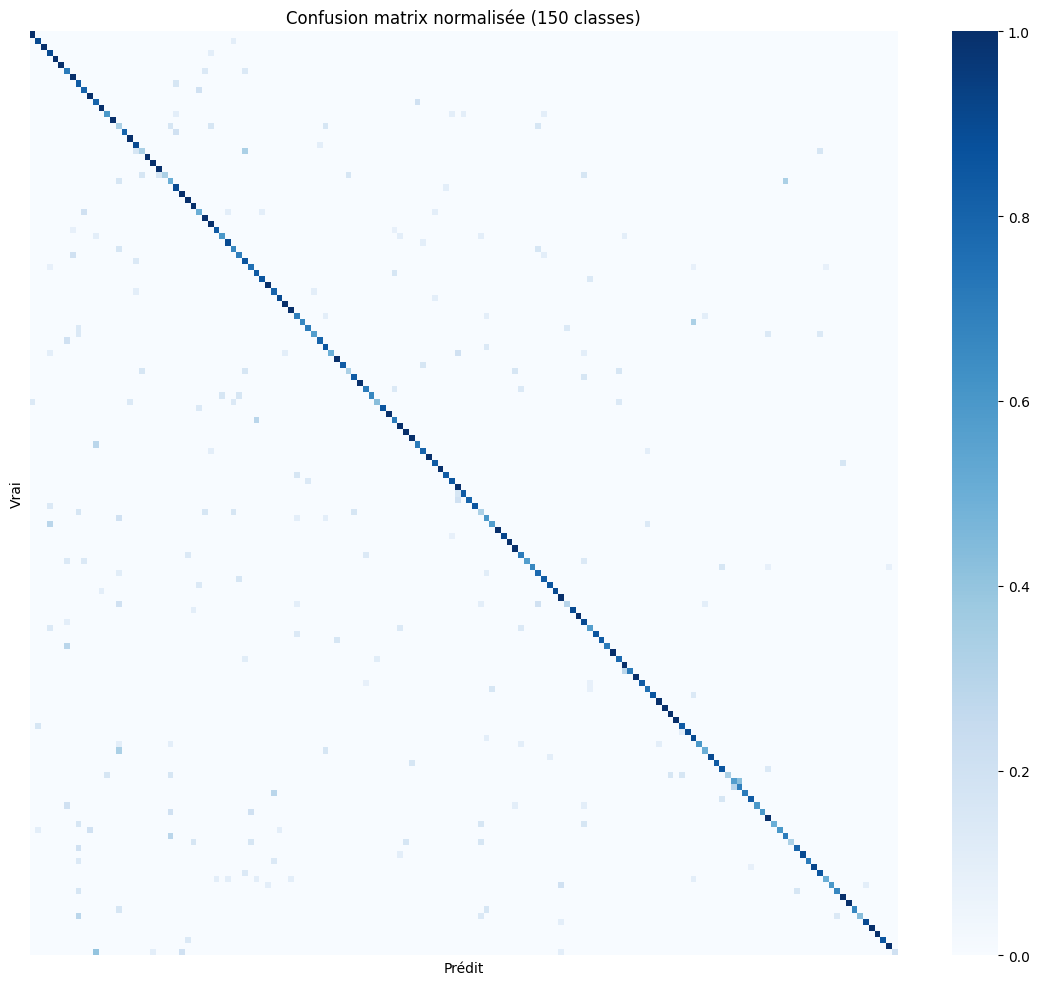

In [14]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title("Confusion matrix normalisée (150 classes)")
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.show()

## Few-shot performance vs. k-shot size

Here we re-split **per experiment** intentionally: each k-shot value
defines its own train/test partition (k images per class for training,
the rest for testing). This is the standard few-shot evaluation protocol
and is independent of the global split used above.


In [15]:
from collections import defaultdict
import random
class_to_idx = defaultdict(list)

for i, label in enumerate(y_encoded):
    class_to_idx[label].append(i)


def build_few_shot_dataset(k):
    train_idx = []
    test_idx = []

    for label, idxs in class_to_idx.items():

        idxs = np.array(idxs, dtype=int)
        np.random.shuffle(idxs)

        k_clamped = min(k, len(idxs) - 1)  

        train_idx.extend(idxs[:k_clamped])
        test_idx.extend(idxs[k_clamped:])

    return np.array(train_idx, dtype=int), np.array(test_idx, dtype=int)

#### gathering the accuracies of each K-shot for different methods
Mobilenet embedding only <br>
KNN on mobilenet embedding <br>
SVM on obilenet embedding <br>

In [16]:
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

value_distribution = Counter(class_counts.values())

k_values = sorted(list(value_distribution.keys()))
accuracies = []
f1_scores = []
n_classes_list = []

for k in k_values:

    n_classes = value_distribution[k]
    n_classes_list.append(n_classes)

    train_idx, test_idx = build_few_shot_dataset(k)

    # Use local names to avoid overwriting the global X_train / X_test
    X_fs_train, y_fs_train = X[train_idx], y_encoded[train_idx]
    X_fs_test,  y_fs_test  = X[test_idx],  y_encoded[test_idx]

    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X_fs_train, y_fs_train)

    y_pred_fs = clf.predict(X_fs_test)

    acc = accuracy_score(y_fs_test, y_pred_fs)
    f1 = f1_score(y_fs_test, y_pred_fs, average='macro', zero_division=0)
    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"k={k} ({n_classes} classes) → accuracy={acc:.4f}, f1={f1:.4f}")


k=26 (1 classes) → accuracy=0.8111, f1=0.7639
k=27 (1 classes) → accuracy=0.8083, f1=0.7687
k=28 (3 classes) → accuracy=0.8156, f1=0.7695
k=29 (4 classes) → accuracy=0.8124, f1=0.7420
k=30 (6 classes) → accuracy=0.8098, f1=0.7089
k=31 (10 classes) → accuracy=0.8183, f1=0.7321
k=32 (12 classes) → accuracy=0.8283, f1=0.7328
k=33 (15 classes) → accuracy=0.8262, f1=0.7050
k=34 (14 classes) → accuracy=0.8338, f1=0.6929
k=35 (6 classes) → accuracy=0.8172, f1=0.7036
k=36 (7 classes) → accuracy=0.8279, f1=0.7106
k=44 (1 classes) → accuracy=0.8441, f1=0.7681
k=46 (1 classes) → accuracy=0.8628, f1=0.7850
k=47 (1 classes) → accuracy=0.8398, f1=0.7569
k=49 (4 classes) → accuracy=0.8597, f1=0.7808
k=50 (52 classes) → accuracy=0.8264, f1=0.7419
k=58 (1 classes) → accuracy=0.8025, f1=0.7384
k=59 (1 classes) → accuracy=0.8411, f1=0.8002
k=60 (11 classes) → accuracy=0.7881, f1=0.7384


In [17]:
from collections import Counter
from sklearn.metrics import accuracy_score
import numpy as np

value_distribution = Counter(class_counts.values())

k_values = sorted(list(value_distribution.keys()))
accuracies_centroid = []
f1_scores_centroid = []
n_classes_list = []

for k in k_values:

    n_classes = value_distribution[k]
    n_classes_list.append(n_classes)

    train_idx, test_idx = build_few_shot_dataset(k)

    X_fs_train, y_fs_train = X[train_idx], y_encoded[train_idx]
    X_fs_test,  y_fs_test  = X[test_idx],  y_encoded[test_idx]

    # Nearest centroid per class (pure embedding similarity, no KNN)
    centroids = {}
    for label in np.unique(y_fs_train):
        centroids[label] = X_fs_train[y_fs_train == label].mean(axis=0)

    centroid_matrix = np.array([centroids[l] for l in sorted(centroids)])
    labels_order = np.array(sorted(centroids))

    # Cosine similarity
    X_norm = X_fs_test / (np.linalg.norm(X_fs_test, axis=1, keepdims=True) + 1e-8)
    C_norm = centroid_matrix / (np.linalg.norm(centroid_matrix, axis=1, keepdims=True) + 1e-8)

    y_pred_fs = labels_order[np.argmax(X_norm @ C_norm.T, axis=1)]

    acc = accuracy_score(y_fs_test, y_pred_fs)
    f1 = f1_score(y_fs_test, y_pred_fs, average='macro', zero_division=0)
    accuracies_centroid.append(acc)
    f1_scores_centroid.append(f1)

    print(f"k={k} ({n_classes} classes) → accuracy={acc:.4f}, f1={f1:.4f}")

k=26 (1 classes) → accuracy=0.8473, f1=0.8014
k=27 (1 classes) → accuracy=0.8543, f1=0.8048
k=28 (3 classes) → accuracy=0.8537, f1=0.7926
k=29 (4 classes) → accuracy=0.8501, f1=0.7900
k=30 (6 classes) → accuracy=0.8471, f1=0.7559
k=31 (10 classes) → accuracy=0.8639, f1=0.7760
k=32 (12 classes) → accuracy=0.8512, f1=0.7597
k=33 (15 classes) → accuracy=0.8604, f1=0.7597
k=34 (14 classes) → accuracy=0.8665, f1=0.7724
k=35 (6 classes) → accuracy=0.8629, f1=0.7609
k=36 (7 classes) → accuracy=0.8605, f1=0.7388
k=44 (1 classes) → accuracy=0.8328, f1=0.7613
k=46 (1 classes) → accuracy=0.8690, f1=0.7952
k=47 (1 classes) → accuracy=0.8641, f1=0.8276
k=49 (4 classes) → accuracy=0.8669, f1=0.7912
k=50 (52 classes) → accuracy=0.8755, f1=0.8222
k=58 (1 classes) → accuracy=0.8951, f1=0.8618
k=59 (1 classes) → accuracy=0.8874, f1=0.8587
k=60 (11 classes) → accuracy=0.7947, f1=0.7521


### SVM on the Mobilenet embedding

In [18]:
from sklearn.svm import SVC

value_distribution = Counter(class_counts.values())

k_values = sorted(list(value_distribution.keys()))
accuracies_svm = []
f1_scores_svm = []
n_classes_list = []

for k in k_values:

    n_classes = value_distribution[k]
    n_classes_list.append(n_classes)

    train_idx, test_idx = build_few_shot_dataset(k)

    X_fs_train, y_fs_train = X[train_idx], y_encoded[train_idx]
    X_fs_test,  y_fs_test  = X[test_idx],  y_encoded[test_idx]

    clf = SVC(kernel="rbf", C=10, gamma="scale")
    clf.fit(X_fs_train, y_fs_train)

    y_pred_fs = clf.predict(X_fs_test)

    acc = accuracy_score(y_fs_test, y_pred_fs)
    f1 = f1_score(y_fs_test, y_pred_fs, average='macro', zero_division=0)
    accuracies_svm.append(acc)
    f1_scores_svm.append(f1)

    print(f"k={k} ({n_classes} classes) → accuracy={acc:.4f}, f1={f1:.4f}")

k=26 (1 classes) → accuracy=0.8755, f1=0.8438
k=27 (1 classes) → accuracy=0.8757, f1=0.8466
k=28 (3 classes) → accuracy=0.8771, f1=0.8303
k=29 (4 classes) → accuracy=0.8847, f1=0.8415
k=30 (6 classes) → accuracy=0.8866, f1=0.8330
k=31 (10 classes) → accuracy=0.8767, f1=0.8088
k=32 (12 classes) → accuracy=0.8851, f1=0.8088
k=33 (15 classes) → accuracy=0.8856, f1=0.8138
k=34 (14 classes) → accuracy=0.8947, f1=0.8254
k=35 (6 classes) → accuracy=0.8976, f1=0.8189
k=36 (7 classes) → accuracy=0.8855, f1=0.7954
k=44 (1 classes) → accuracy=0.9116, f1=0.8521
k=46 (1 classes) → accuracy=0.9127, f1=0.8734
k=47 (1 classes) → accuracy=0.8835, f1=0.8259
k=49 (4 classes) → accuracy=0.8993, f1=0.8312
k=50 (52 classes) → accuracy=0.9170, f1=0.8939
k=58 (1 classes) → accuracy=0.8457, f1=0.8018
k=59 (1 classes) → accuracy=0.8940, f1=0.8620
k=60 (11 classes) → accuracy=0.8675, f1=0.8333


In [19]:
from sklearn.svm import SVC

value_distribution = Counter(class_counts.values())

k_values = sorted(list(value_distribution.keys()))
accuracies_svm_linear = []
f1_scores_svm_linear = []
n_classes_list = []

for k in k_values:

    n_classes = value_distribution[k]
    n_classes_list.append(n_classes)

    train_idx, test_idx = build_few_shot_dataset(k)

    X_fs_train, y_fs_train = X[train_idx], y_encoded[train_idx]
    X_fs_test,  y_fs_test  = X[test_idx],  y_encoded[test_idx]

    clf = SVC(kernel="linear", C=1, gamma="scale")
    clf.fit(X_fs_train, y_fs_train)

    y_pred_fs = clf.predict(X_fs_test)

    acc = accuracy_score(y_fs_test, y_pred_fs)
    f1 = f1_score(y_fs_test, y_pred_fs, average='macro', zero_division=0)
    accuracies_svm_linear.append(acc)
    f1_scores_svm_linear.append(f1)

    print(f"k={k} ({n_classes} classes) → accuracy={acc:.4f}, f1={f1:.4f}")

k=26 (1 classes) → accuracy=0.8874, f1=0.8476
k=27 (1 classes) → accuracy=0.8866, f1=0.8472
k=28 (3 classes) → accuracy=0.8907, f1=0.8570
k=29 (4 classes) → accuracy=0.8705, f1=0.8058
k=30 (6 classes) → accuracy=0.8922, f1=0.8236
k=31 (10 classes) → accuracy=0.8961, f1=0.8330
k=32 (12 classes) → accuracy=0.8838, f1=0.8162
k=33 (15 classes) → accuracy=0.9002, f1=0.8139
k=34 (14 classes) → accuracy=0.8932, f1=0.7952
k=35 (6 classes) → accuracy=0.8968, f1=0.8329
k=36 (7 classes) → accuracy=0.9006, f1=0.8059
k=44 (1 classes) → accuracy=0.9228, f1=0.8904
k=46 (1 classes) → accuracy=0.9064, f1=0.8604
k=47 (1 classes) → accuracy=0.9053, f1=0.8551
k=49 (4 classes) → accuracy=0.8777, f1=0.8137
k=50 (52 classes) → accuracy=0.8755, f1=0.8183
k=58 (1 classes) → accuracy=0.8951, f1=0.8728
k=59 (1 classes) → accuracy=0.8477, f1=0.8091
k=60 (11 classes) → accuracy=0.8874, f1=0.8565


In [20]:
from sklearn.linear_model import LogisticRegression

value_distribution = Counter(class_counts.values())

k_values = sorted(list(value_distribution.keys()))
accuracies_logistic_regression = []
f1_scores_logistic_regression = []
n_classes_list = []

for k in k_values:

    n_classes = value_distribution[k]
    n_classes_list.append(n_classes)

    train_idx, test_idx = build_few_shot_dataset(k)

    X_fs_train, y_fs_train = X[train_idx], y_encoded[train_idx]
    X_fs_test,  y_fs_test  = X[test_idx],  y_encoded[test_idx]

    clf = LogisticRegression(C=10, max_iter=1000, random_state=42)
    clf.fit(X_fs_train, y_fs_train)

    y_pred_fs = clf.predict(X_fs_test)

    acc = accuracy_score(y_fs_test, y_pred_fs)
    f1 = f1_score(y_fs_test, y_pred_fs, average='macro', zero_division=0)
    accuracies_logistic_regression.append(acc)
    f1_scores_logistic_regression.append(f1)

    print(f"k={k} ({n_classes} classes) → accuracy={acc:.4f}, f1={f1:.4f}")

k=26 (1 classes) → accuracy=0.8759, f1=0.8316
k=27 (1 classes) → accuracy=0.9035, f1=0.8544
k=28 (3 classes) → accuracy=0.8917, f1=0.8463
k=29 (4 classes) → accuracy=0.8973, f1=0.8390
k=30 (6 classes) → accuracy=0.9001, f1=0.8299
k=31 (10 classes) → accuracy=0.9010, f1=0.8163
k=32 (12 classes) → accuracy=0.9008, f1=0.7992
k=33 (15 classes) → accuracy=0.9086, f1=0.8144
k=34 (14 classes) → accuracy=0.8895, f1=0.7910
k=35 (6 classes) → accuracy=0.8936, f1=0.8065
k=36 (7 classes) → accuracy=0.8939, f1=0.7941
k=44 (1 classes) → accuracy=0.9051, f1=0.8435
k=46 (1 classes) → accuracy=0.8940, f1=0.8256
k=47 (1 classes) → accuracy=0.8883, f1=0.8442
k=49 (4 classes) → accuracy=0.8885, f1=0.8459
k=50 (52 classes) → accuracy=0.9170, f1=0.8911
k=58 (1 classes) → accuracy=0.8951, f1=0.8552
k=59 (1 classes) → accuracy=0.8874, f1=0.8521
k=60 (11 classes) → accuracy=0.9272, f1=0.9062


In [21]:
import pickle
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from collections import Counter



import os
import pickle
from PIL import Image

import torch
import torchvision.transforms as transforms
from torchvision import models

# =========================
# CONFIG
# =========================

DATASET_PATH = "dataset/dataset"
OUTPUT_FILE = "embeddings_densenet.pkl"

# =========================
# DEVICE
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# MODEL
# =========================

# Load pretrained DenseNet
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Remove classifier head
model = model.features

# Evaluation mode
model.eval()
model.to(device)

# =========================
# IMAGE TRANSFORM
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# STORAGE
# =========================

data = []

# =========================
# LOOP OVER DATASET
# =========================


from sklearn.model_selection import train_test_split

# =========================
# COLLECT ALL PATHS FIRST
# =========================

all_paths = []
all_labels = []

valid_extensions = {".jpg", ".jpeg", ".png", ".webp"}
for label in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue
    for filename in sorted(os.listdir(class_path)):
        ext = os.path.splitext(filename)[1].lower()
        image_path = os.path.join(class_path, filename)
        if os.path.isfile(image_path) and ext in valid_extensions:
            all_paths.append(image_path)
            all_labels.append(label)

# =========================
# SPLIT BEFORE EMBEDDING
# =========================

paths_train, paths_test, labels_train, labels_test = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

split_map = {p: "train" for p in paths_train}
split_map.update({p: "test" for p in paths_test})



for image_path, label in zip(all_paths, all_labels):
    ext = os.path.splitext(image_path)[1].lower()
    try:
        image = Image.open(image_path).convert("RGB")
        img_tensor = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            features = model(img_tensor)
            features = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
            embedding = features.view(-1).cpu().numpy()
        data.append({
            "label": label,
            "image": image_path,
            "embedding": embedding,
            "split": split_map[image_path]  
        })
    except Exception as e:
        print(f"Error with {image_path}: {e}")

        
# =========================
# SAVE
# =========================

with open(OUTPUT_FILE, "wb") as f:
    pickle.dump(data, f)

print(f"\nSaved embeddings to {OUTPUT_FILE}")



Saved embeddings to embeddings_densenet.pkl


In [22]:


with open("embeddings_densenet.pkl", "rb") as f:
    data_densenet = pickle.load(f)

train_data = [d for d in data_densenet if d["split"] == "train"]
test_data  = [d for d in data_densenet if d["split"] == "test"]

X = np.array([d["embedding"] for d in data_densenet])
y = np.array([d["label"]     for d in data_densenet])

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

value_distribution = Counter(class_counts.values())
k_values = sorted(list(value_distribution.keys()))
accuracies_densenet_lr = []
f1_scores_densenet_lr = []
n_classes_list = []

for k in k_values:

    n_classes = value_distribution[k]
    n_classes_list.append(n_classes)

    train_idx, test_idx = build_few_shot_dataset(k)

    X_fs_train, y_fs_train = X[train_idx], y_encoded[train_idx]
    X_fs_test,  y_fs_test  = X[test_idx],  y_encoded[test_idx]

    clf = LogisticRegression(C=10, max_iter=1000, random_state=42)
    clf.fit(X_fs_train, y_fs_train)

    y_pred_fs = clf.predict(X_fs_test)

    acc = accuracy_score(y_fs_test, y_pred_fs)
    f1 = f1_score(y_fs_test, y_pred_fs, average='macro', zero_division=0)
    accuracies_densenet_lr.append(acc)
    f1_scores_densenet_lr.append(f1)

    print(f"k={k} ({n_classes} classes) → accuracy={acc:.4f}, f1={f1:.4f}")

k=26 (1 classes) → accuracy=0.9130, f1=0.8835
k=27 (1 classes) → accuracy=0.9162, f1=0.8861
k=28 (3 classes) → accuracy=0.9083, f1=0.8664
k=29 (4 classes) → accuracy=0.9182, f1=0.8714
k=30 (6 classes) → accuracy=0.9216, f1=0.8780
k=31 (10 classes) → accuracy=0.9204, f1=0.8579
k=32 (12 classes) → accuracy=0.9249, f1=0.8794
k=33 (15 classes) → accuracy=0.9309, f1=0.8817
k=34 (14 classes) → accuracy=0.9206, f1=0.8494
k=35 (6 classes) → accuracy=0.9275, f1=0.8648
k=36 (7 classes) → accuracy=0.9256, f1=0.8573
k=44 (1 classes) → accuracy=0.9212, f1=0.8536
k=46 (1 classes) → accuracy=0.9314, f1=0.9007
k=47 (1 classes) → accuracy=0.9248, f1=0.8939
k=49 (4 classes) → accuracy=0.9353, f1=0.9141
k=50 (52 classes) → accuracy=0.9396, f1=0.9020
k=58 (1 classes) → accuracy=0.9383, f1=0.9225
k=59 (1 classes) → accuracy=0.9272, f1=0.9040
k=60 (11 classes) → accuracy=0.9007, f1=0.8731


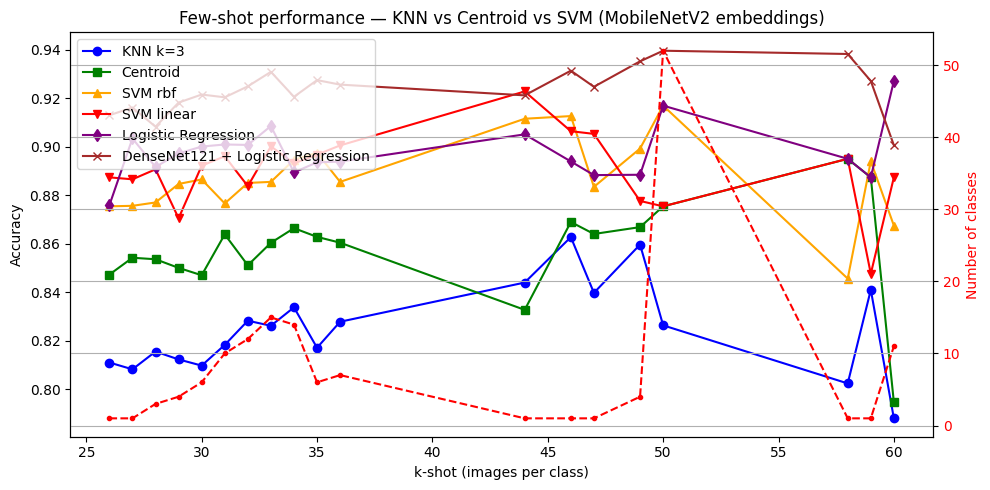

In [23]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_values, accuracies,                          marker="o", color="blue",  label="KNN k=3")
ax1.plot(k_values, accuracies_centroid,                 marker="s", color="green", label="Centroid")
ax1.plot(k_values, accuracies_svm,                      marker="^", color="orange",label="SVM rbf")
ax1.plot(k_values, accuracies_svm_linear,               marker="v", color="red",label="SVM linear")
ax1.plot(k_values, accuracies_logistic_regression,      marker="d", color="purple",label="Logistic Regression")
ax1.plot(k_values, accuracies_densenet_lr,            marker="x", color="brown",label="DenseNet121 + Logistic Regression")


ax1.set_xlabel("k-shot (images per class)")
ax1.set_ylabel("Accuracy")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(k_values, n_classes_list, marker=".", color="red", linestyle="--", label="Nb classes")
ax2.set_ylabel("Number of classes", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Few-shot performance — KNN vs Centroid vs SVM (MobileNetV2 embeddings)")
fig.tight_layout()
plt.grid()
plt.show()

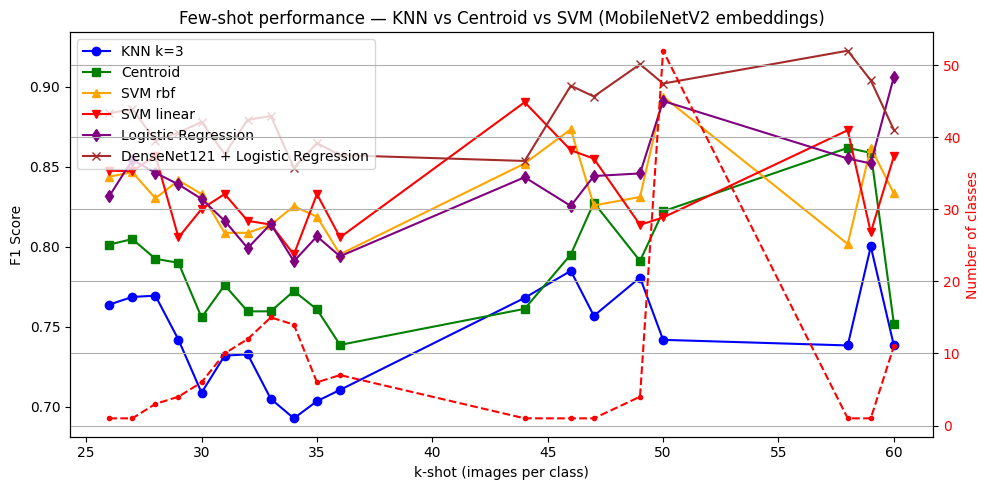

In [24]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_values, f1_scores,                          marker="o", color="blue",  label="KNN k=3")
ax1.plot(k_values, f1_scores_centroid,                 marker="s", color="green", label="Centroid")
ax1.plot(k_values, f1_scores_svm,                      marker="^", color="orange",label="SVM rbf")
ax1.plot(k_values, f1_scores_svm_linear,               marker="v", color="red",label="SVM linear")
ax1.plot(k_values, f1_scores_logistic_regression,      marker="d", color="purple",label="Logistic Regression")
ax1.plot(k_values, f1_scores_densenet_lr,            marker="x", color="brown",label="DenseNet121 + Logistic Regression")


ax1.set_xlabel("k-shot (images per class)")
ax1.set_ylabel("F1 Score")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(k_values, n_classes_list, marker=".", color="red", linestyle="--", label="Nb classes")
ax2.set_ylabel("Number of classes", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Few-shot performance — KNN vs Centroid vs SVM (MobileNetV2 embeddings)")
fig.tight_layout()
plt.grid()
plt.show()

In [25]:
# Average of each method across all k values
avg_knn = np.mean(accuracies)
avg_centroid = np.mean(accuracies_centroid)
avg_svm = np.mean(accuracies_svm)   

print(f"\nAverage accuracy across all k values:")
print(f"KNN k=3: {avg_knn:.4f}")
print(f"Centroid: {avg_centroid:.4f}")
print(f"SVM: {avg_svm:.4f}")
print(f"SVM linear: {np.mean(accuracies_svm_linear):.4f}")
print(f"Logistic Regression: {np.mean(accuracies_logistic_regression):.4f}")
print(f"DenseNet121 + Logistic Regression: {np.mean(accuracies_densenet_lr):.4f}")


Average accuracy across all k values:
KNN k=3: 0.8249
Centroid: 0.8581
SVM: 0.8872
SVM linear: 0.8903
Logistic Regression: 0.8978
DenseNet121 + Logistic Regression: 0.9235


## Conclusion
The results demonstrate a clear progression, with DenseNet121 + Logistic Regression reaching 92.53% accuracy across 155 classes. <br>
This is  significant improvement over MobileNetV2-based approaches without any additional trainable parameters. Lightweight classifiers such as Logistic Regression consistently outperformed more complex kernel methods, suggesting that the embedding space alone carries sufficient discriminative information. <br>
<br>
In contrast, the top-ranked Kaggle solution for Animals-10 achieves ~98% accuracy by appending a 3-million-parameter neural network on top of MobileNetV2 (and with only handles 10 classes). This highlights a common pitfall in applied ML: adding model complexity yields diminishing returns, especially when a well-chosen backbone and a simple linear classifier already capture the underlying structure effectively. 

### Bonus with a Yolov model from openai

In [26]:
import os, pickle
from PIL import Image
import torch
import clip
from sklearn.model_selection import train_test_split

DATASET_PATH = "dataset/dataset"
OUTPUT_FILE  = "embeddings_clip.pkl"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

# Collect all paths
all_paths, all_labels = [], []
valid_extensions = {".jpg", ".jpeg", ".png", ".webp"}
for label in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue
    for filename in sorted(os.listdir(class_path)):
        image_path = os.path.join(class_path, filename)
        ext = os.path.splitext(filename)[1].lower()
        if os.path.isfile(image_path) and ext in valid_extensions:
            all_paths.append(image_path)
            all_labels.append(label)

# Split before embedding
paths_train, paths_test, labels_train, labels_test = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
split_map = {p: "train" for p in paths_train}
split_map.update({p: "test" for p in paths_test})

# Generate embeddings
data = []
for image_path, label in zip(all_paths, all_labels):
    try:
        image = Image.open(image_path).convert("RGB")
        img_tensor = preprocess(image).unsqueeze(0).to(device)
        with torch.no_grad():
            embedding = model.encode_image(img_tensor).cpu().numpy().flatten()
        data.append({
            "label": label,
            "image": image_path,
            "embedding": embedding,
            "split": split_map[image_path]
        })
    except Exception as e:
        print(f"Error with {image_path}: {e}")

with open(OUTPUT_FILE, "wb") as f:
    pickle.dump(data, f)

print(f"Saved {len(data)} embeddings to {OUTPUT_FILE}")

Saved 6270 embeddings to embeddings_clip.pkl


In [27]:
import pickle
import numpy as np
from sklearn.preprocessing import LabelEncoder

with open("embeddings_clip.pkl", "rb") as f:
    data_clip = pickle.load(f)

X = np.array([d["embedding"] for d in data_clip])
y = np.array([d["label"]     for d in data_clip])

encoder_clip = LabelEncoder()
y_encoded = encoder_clip.fit_transform(y)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from collections import Counter

value_distribution = Counter(class_counts.values())
k_values = sorted(list(value_distribution.keys()))
accuracies_clip_lr = []
f1_scores_clip_lr = []
n_classes_list = []

for k in k_values:
    n_classes = value_distribution[k]
    n_classes_list.append(n_classes)

    train_idx, test_idx = build_few_shot_dataset(k)

    X_fs_train, y_fs_train = X[train_idx], y_encoded[train_idx]
    X_fs_test,  y_fs_test  = X[test_idx],  y_encoded[test_idx]

    clf = LogisticRegression(C=10, max_iter=1000, random_state=42)
    clf.fit(X_fs_train, y_fs_train)

    acc = accuracy_score(y_fs_test, clf.predict(X_fs_test))
    f1 = f1_score(y_fs_test, clf.predict(X_fs_test), average='macro', zero_division=0)
    accuracies_clip_lr.append(acc)
    f1_scores_clip_lr.append(f1)

    print(f"k={k} ({n_classes} classes) → accuracy={acc:.4f}, f1={f1:.4f}")

print(f"\nAverage: {np.mean(accuracies_clip_lr):.4f}")

k=26 (1 classes) → accuracy=0.9122, f1=0.8857
k=27 (1 classes) → accuracy=0.9258, f1=0.8870
k=28 (3 classes) → accuracy=0.9210, f1=0.8853
k=29 (4 classes) → accuracy=0.9156, f1=0.8581
k=30 (6 classes) → accuracy=0.9289, f1=0.8862
k=31 (10 classes) → accuracy=0.9386, f1=0.8802
k=32 (12 classes) → accuracy=0.9328, f1=0.8840
k=33 (15 classes) → accuracy=0.9372, f1=0.8709
k=34 (14 classes) → accuracy=0.9303, f1=0.8515
k=35 (6 classes) → accuracy=0.9362, f1=0.8494
k=36 (7 classes) → accuracy=0.9282, f1=0.8674
k=44 (1 classes) → accuracy=0.9518, f1=0.9096
k=46 (1 classes) → accuracy=0.9397, f1=0.9296
k=47 (1 classes) → accuracy=0.9442, f1=0.9035
k=49 (4 classes) → accuracy=0.9353, f1=0.8955
k=50 (52 classes) → accuracy=0.9358, f1=0.9000
k=58 (1 classes) → accuracy=0.9444, f1=0.9316
k=59 (1 classes) → accuracy=0.9205, f1=0.8951
k=60 (11 classes) → accuracy=0.9007, f1=0.8775

Average: 0.9305


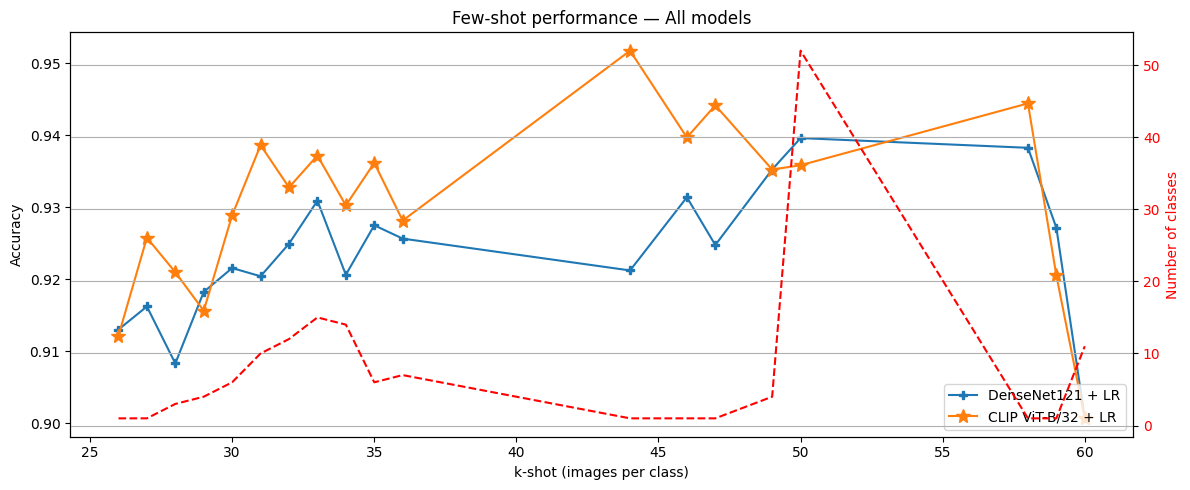

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(k_values, accuracies_densenet_lr, marker="P", label="DenseNet121 + LR")
ax1.plot(k_values, accuracies_clip_lr,    marker="*", markersize=10, label="CLIP ViT-B/32 + LR")

ax1.set_xlabel("k-shot (images per class)")
ax1.set_ylabel("Accuracy")
ax1.legend(loc="lower right")

ax2 = ax1.twinx()
ax2.plot(k_values, n_classes_list, linestyle="--", color="red", label="Nb classes")
ax2.set_ylabel("Number of classes", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Few-shot performance — All models")
fig.tight_layout()
plt.grid()
plt.show()

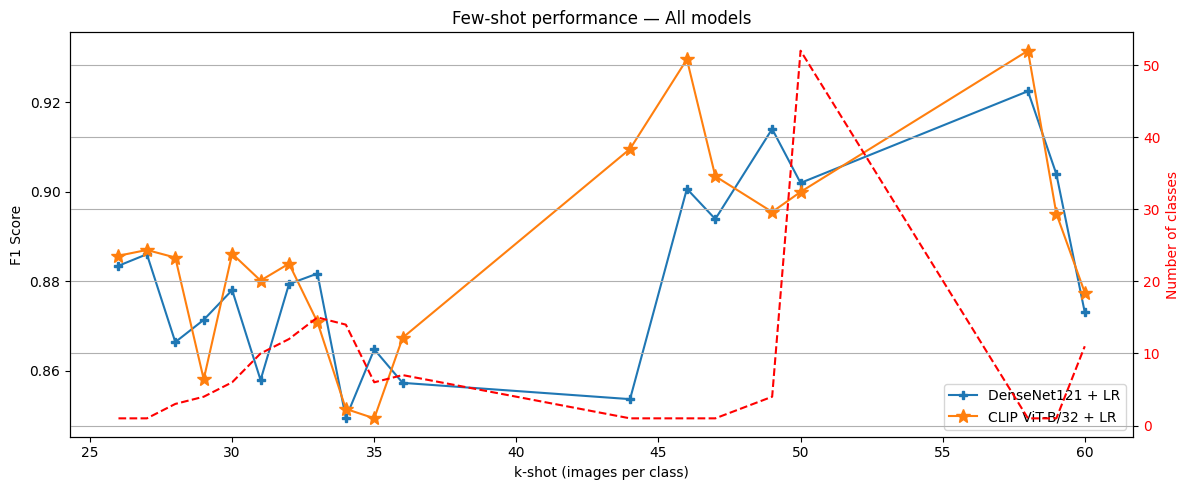

In [30]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(k_values, f1_scores_densenet_lr, marker="P", label="DenseNet121 + LR")
ax1.plot(k_values, f1_scores_clip_lr,    marker="*", markersize=10, label="CLIP ViT-B/32 + LR")

ax1.set_xlabel("k-shot (images per class)")
ax1.set_ylabel("F1 Score")
ax1.legend(loc="lower right")

ax2 = ax1.twinx()
ax2.plot(k_values, n_classes_list, linestyle="--", color="red", label="Nb classes")
ax2.set_ylabel("Number of classes", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Few-shot performance — All models")
fig.tight_layout()
plt.grid()
plt.show()

In [31]:
print(f"Logistic Regression: {np.mean(accuracies_logistic_regression):.4f}")
print(f"DenseNet121 + Logistic Regression: {np.mean(accuracies_densenet_lr):.4f}")
print(f"CLIP ViT-B/32 + Logistic Regression: {np.mean(accuracies_clip_lr):.4f}")
print("----------------------------")
print(f"\nAverage F1-Score:")
print(f"Logistic Regression: {np.mean(f1_scores_logistic_regression):.4f}")
print(f"DenseNet121 + Logistic Regression: {np.mean(f1_scores_densenet_lr):.4f}")
print(f"CLIP ViT-B/32 + Logistic Regression: {np.mean(f1_scores_clip_lr):.4f}")

Logistic Regression: 0.8978
DenseNet121 + Logistic Regression: 0.9235
CLIP ViT-B/32 + Logistic Regression: 0.9305
----------------------------

Average F1-Score:
Logistic Regression: 0.8361
DenseNet121 + Logistic Regression: 0.8810
CLIP ViT-B/32 + Logistic Regression: 0.8867


ViT slightly better when less images (<45), and DenseNet better when higher number of images. Not really significant

colima start --memory 4 --disk 20 <br>
docker build -t animals-detection ./API_App <br>
docker run -p 8000:8000 animals-detection <br>